# 决策树分类 - W3Classif 数据集

本笔记本使用决策树算法对 w3classif.csv 数据集进行二分类任务。该数据集包含两个特征和一个目标变量（0或1）。

## 目标
- 使用决策树训练分类模型
- 评估模型性能
- 可视化决策边界和决策树结构
- 分析特征重要性

In [11]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# 设置中文字体和图形显示
plt.rcParams["font.sans-serif"] = ["SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.style.use("default")

print("所有库导入成功！")

所有库导入成功！


In [12]:
# Load data and prepare for training
df = pd.read_csv(
    "../datasets/w3classif.csv", header=None, names=["feature1", "feature2", "target"]
)

# Prepare features and target
X = df[["feature1", "feature2"]]
y = df["target"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Training set class distribution:\n{y_train.value_counts()}")
print(f"Testing set class distribution:\n{y_test.value_counts()}")

Training set size: (320, 2)
Testing set size: (80, 2)
Training set class distribution:
target
1    160
0    160
Name: count, dtype: int64
Testing set class distribution:
target
0    40
1    40
Name: count, dtype: int64


In [13]:
# Create and train decision tree model
dt_classifier = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,  # Limit tree depth to prevent overfitting
    min_samples_split=10,  # Minimum samples required to split an internal node
    min_samples_leaf=5,  # Minimum samples required to be at a leaf node
)

# Train the model
dt_classifier.fit(X_train, y_train)

# Make predictions
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

print("Decision tree model training completed!")

Decision tree model training completed!


Model Performance Evaluation
Training accuracy: 0.9688
Testing accuracy: 0.9625

Test set classification report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        40
           1       0.95      0.97      0.96        40

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



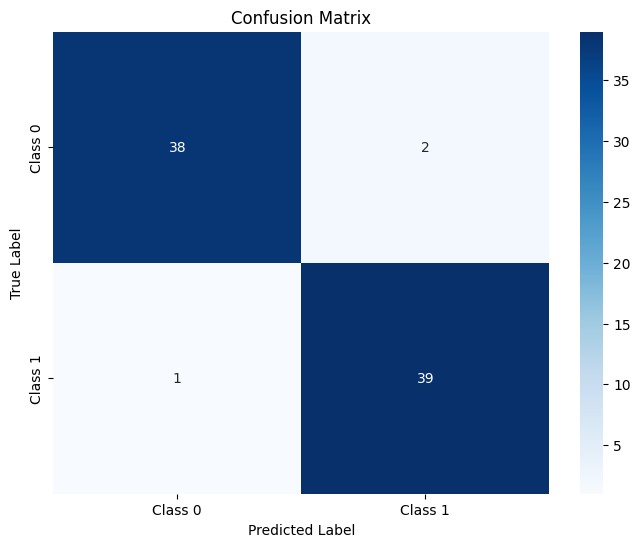

In [14]:
# Model evaluation
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 50)
print("Model Performance Evaluation")
print("=" * 50)
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Testing accuracy: {test_accuracy:.4f}")

# Detailed classification report
print("\nTest set classification report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"],
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

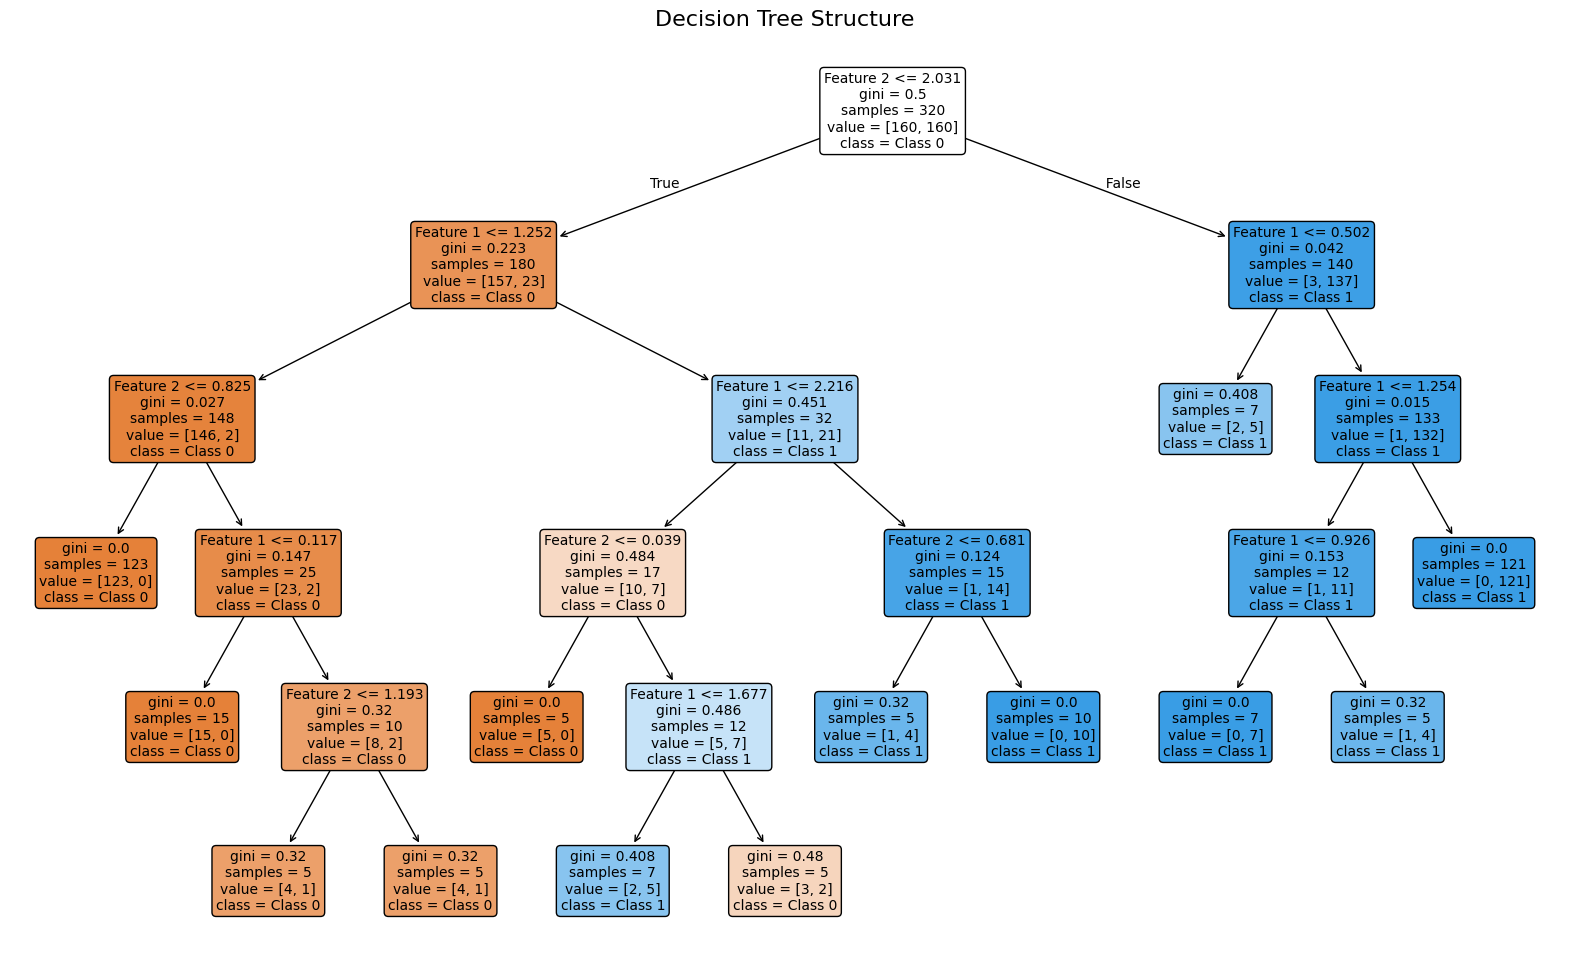

Decision tree rules:
|--- Feature 2 <= 2.03
|   |--- Feature 1 <= 1.25
|   |   |--- Feature 2 <= 0.83
|   |   |   |--- class: 0
|   |   |--- Feature 2 >  0.83
|   |   |   |--- Feature 1 <= 0.12
|   |   |   |   |--- class: 0
|   |   |   |--- Feature 1 >  0.12
|   |   |   |   |--- Feature 2 <= 1.19
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Feature 2 >  1.19
|   |   |   |   |   |--- class: 0
|   |--- Feature 1 >  1.25
|   |   |--- Feature 1 <= 2.22
|   |   |   |--- Feature 2 <= 0.04
|   |   |   |   |--- class: 0
|   |   |   |--- Feature 2 >  0.04
|   |   |   |   |--- Feature 1 <= 1.68
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Feature 1 >  1.68
|   |   |   |   |   |--- class: 0
|   |   |--- Feature 1 >  2.22
|   |   |   |--- Feature 2 <= 0.68
|   |   |   |   |--- class: 1
|   |   |   |--- Feature 2 >  0.68
|   |   |   |   |--- class: 1
|--- Feature 2 >  2.03
|   |--- Feature 1 <= 0.50
|   |   |--- class: 1
|   |--- Feature 1 >  0.50
|   |   |--- Feature 1 <= 1.25


In [15]:
# Visualize decision tree
plt.figure(figsize=(20, 12))
plot_tree(
    dt_classifier,
    feature_names=["Feature 1", "Feature 2"],
    class_names=["Class 0", "Class 1"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree Structure", fontsize=16)
plt.show()

# Text representation of the tree
print("Decision tree rules:")
tree_rules = export_text(dt_classifier, feature_names=["Feature 1", "Feature 2"])
print(tree_rules)

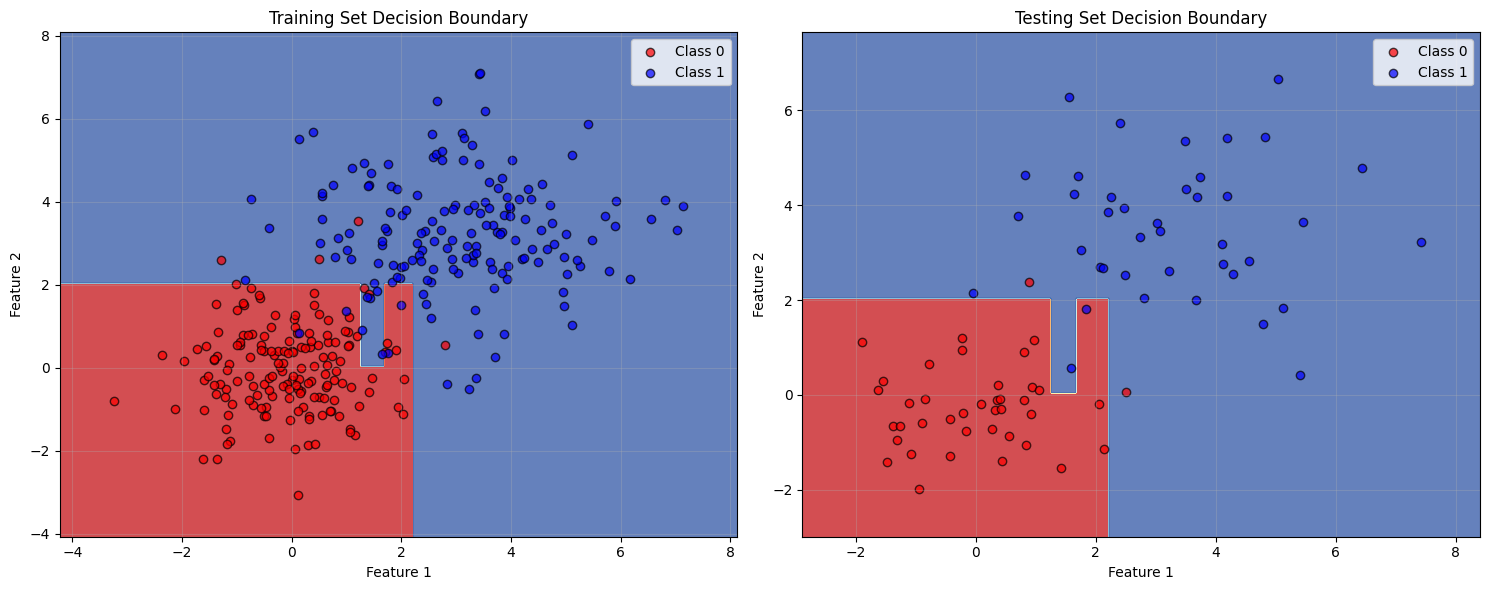

In [16]:
# Visualize decision boundaries
def plot_decision_boundary(X, y, classifier, title):
    """Plot decision boundary"""
    h = 0.02  # Step size in the mesh
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict on mesh points
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Plot data points
    colors = ["red", "blue"]
    for i, target in enumerate([0, 1]):
        mask = y == target
        plt.scatter(
            X[mask].iloc[:, 0],
            X[mask].iloc[:, 1],
            c=colors[i],
            label=f"Class {target}",
            edgecolors="black",
            alpha=0.7,
        )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)


# Plot decision boundaries for training and testing sets
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plot_decision_boundary(
    X_train, y_train, dt_classifier, "Training Set Decision Boundary"
)

plt.subplot(1, 2, 2)
plot_decision_boundary(X_test, y_test, dt_classifier, "Testing Set Decision Boundary")

plt.tight_layout()
plt.show()

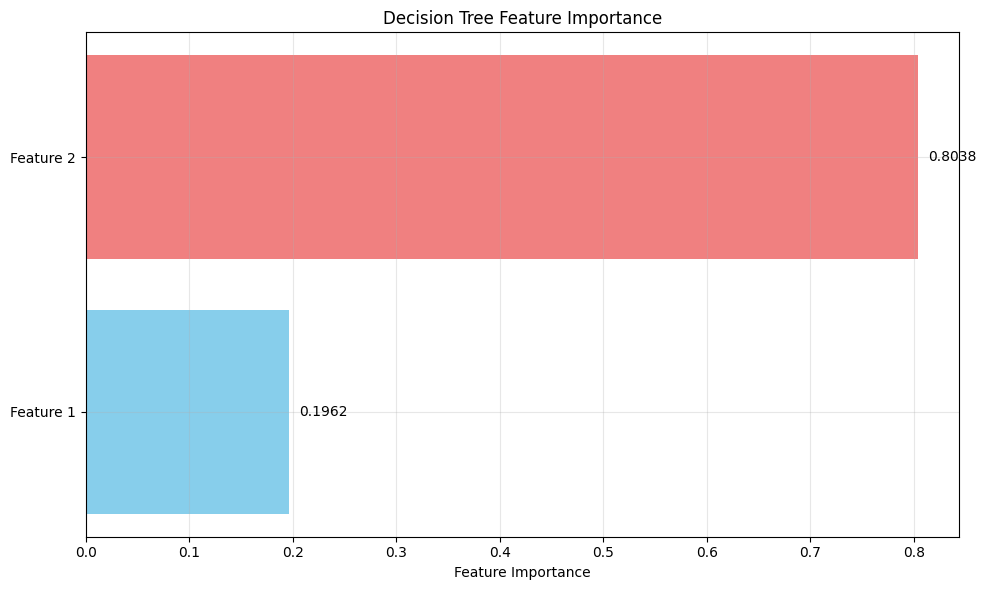

Feature importance analysis:
Feature 1: 0.1962
Feature 2: 0.8038


In [17]:
# Feature importance analysis
feature_importance = dt_classifier.feature_importances_
feature_names = ["Feature 1", "Feature 2"]

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance, color=["skyblue", "lightcoral"])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(feature_importance):
    plt.text(v + 0.01, i, f"{v:.4f}", va="center")

plt.tight_layout()
plt.show()

print("Feature importance analysis:")
for name, importance in zip(feature_names, feature_importance):
    print(f"{name}: {importance:.4f}")

In [18]:
# Hyperparameter tuning
print("Performing hyperparameter tuning...")

# Define parameter grid
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}

# Use grid search
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Best parameter combination:")
print(grid_search.best_params_)
print(f"\nBest cross-validation score: {grid_search.best_score_:.4f}")

# Train model with best parameters
best_dt = grid_search.best_estimator_
y_test_pred_best = best_dt.predict(X_test)
best_test_accuracy = accuracy_score(y_test, y_test_pred_best)

print(f"Optimized test accuracy: {best_test_accuracy:.4f}")
print(f"Original model test accuracy: {test_accuracy:.4f}")
print(f"Accuracy improvement: {best_test_accuracy - test_accuracy:.4f}")

Performing hyperparameter tuning...
Best parameter combination:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}

Best cross-validation score: 0.9563
Optimized test accuracy: 0.9750
Original model test accuracy: 0.9625
Accuracy improvement: 0.0125
